In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

repo_root = Path.cwd().resolve().parent
exp_dir = repo_root / 'exp'
exp_dir


WindowsPath('C:/Users/prana/Documents/Projects/berkeley/cs285/hw/hw3/exp')

In [2]:
def collect_experiments(names: dict):
    exps = list(exp_dir.glob('*/log.csv'))

    frames = []

    for key, experiment in names.items():
        for p in exps:
            if p.parent.name.startswith(key):
                run_name = p.parent.name
                df = pd.read_csv(p)
                df['experiment'] = experiment
                df['run_name'] = run_name
                frames.append(df)
                break

    plot_df = pd.concat(frames, ignore_index=True)

    plot_df["experiment"] = pd.Categorical(
        plot_df["experiment"],
        categories=list(names.values()),
        ordered=True,
    )

    print(
        plot_df[['experiment', 'run_name']]
        .drop_duplicates()
        .to_string(index=False)
    )

    return plot_df

In [3]:
def make_plot(
    file_name: str, 
    df, 
    title: str, 
    y: str = 'Eval_AverageReturn', 
    y_label: str = 'Return', 
    x = 'step', 
    x_label='Training Steps', 
    std=None,
    smooth = None,
    legend=None,
):
    sns.set_theme(style='whitegrid')
    if smooth is not None:
        df = df.copy()
        df = df.sort_values(x)
    
        df[y] = (
            df
            .groupby("experiment", observed=True)[y]
            .transform(lambda s: s.ewm(alpha=smooth, adjust=False).mean())
        )
        
        if std is not None:
            df[std] = (
                df
                .groupby("experiment", observed=True)[std]
                .transform(lambda s: s.ewm(alpha=smooth, adjust=False).mean())
            )


    if isinstance(file_name, str):
        fig, ax = plt.subplots(figsize=(8, 5), dpi=140)
    else:
        fig = None
        ax = file_name
    
    sns.lineplot(
        data=df,
        x=x,
        y=y,
        hue='experiment',
        ax=ax,
    )
    if std is not None:
        line_colors = {}
        for line in ax.lines:
            label = line.get_label()
            if label != "_nolegend_":
                line_colors[label] = line.get_color()

    
        for exp, sub in df.groupby("experiment", sort=False):
            sub = sub.sort_values(x)
            c = line_colors.get(exp)
        
            lo = sub[y] - sub[std]
            hi = sub[y] + sub[std]
        
            ax.fill_between(sub[x], lo, hi, color=c, alpha=0.2, edgecolor="none")

    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    if legend is None:
        legend = len(df['experiment'].unique()) > 1
    ax.legend(title='Experiment').set_visible(legend)
    plt.tight_layout()
    
    if fig:
        out_path = repo_root / 'scripts' / file_name
        fig.savefig(out_path, bbox_inches='tight')
        print(f'Saved figure to: {out_path}')
        plt.show()


  experiment                            run_name
cartpole_dqn CartPole-v1_dqn_sd1_20260312_124015
Saved figure to: C:\Users\prana\Documents\Projects\berkeley\cs285\hw\hw3\scripts\2_4_cartpole_dqn.png


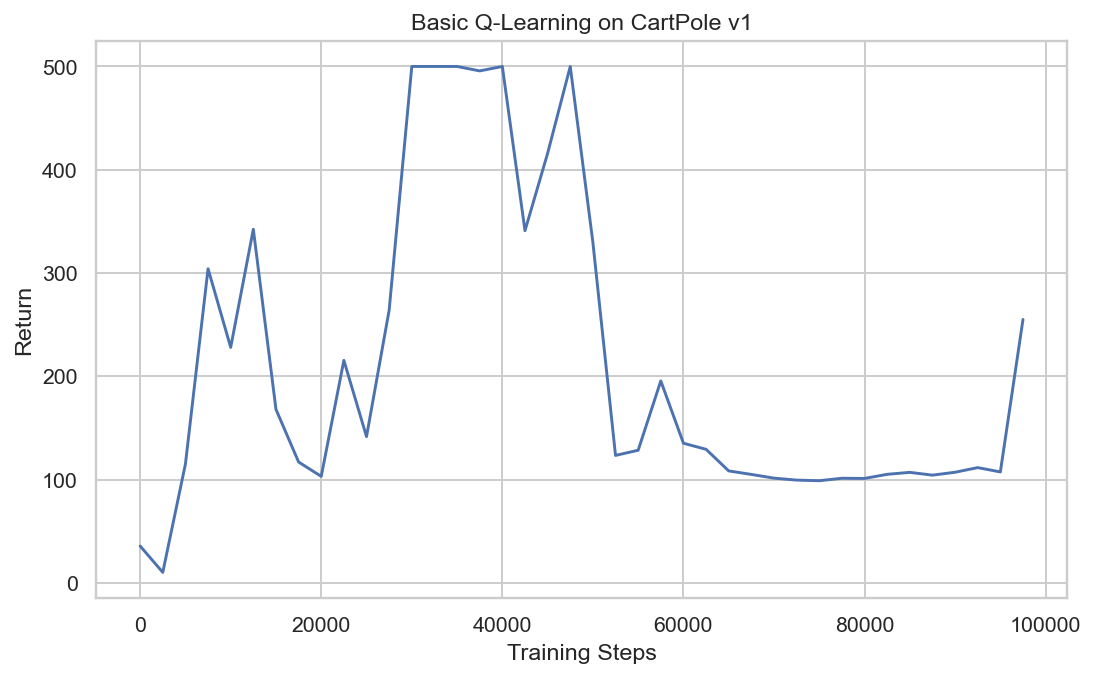

In [4]:
cartpole_sb = collect_experiments({
    'CartPole-v1_dqn_sd1_20260312_124015': 'cartpole_dqn',
})
make_plot('2_4_cartpole_dqn.png', cartpole_sb, 'Basic Q-Learning on CartPole v1')

      experiment                               run_name
lunarlander_ddqn LunarLander-v2_dqn_sd1_20260312_125432
Saved figure to: C:\Users\prana\Documents\Projects\berkeley\cs285\hw\hw3\scripts\2_5_lunarlander_ddqn.png


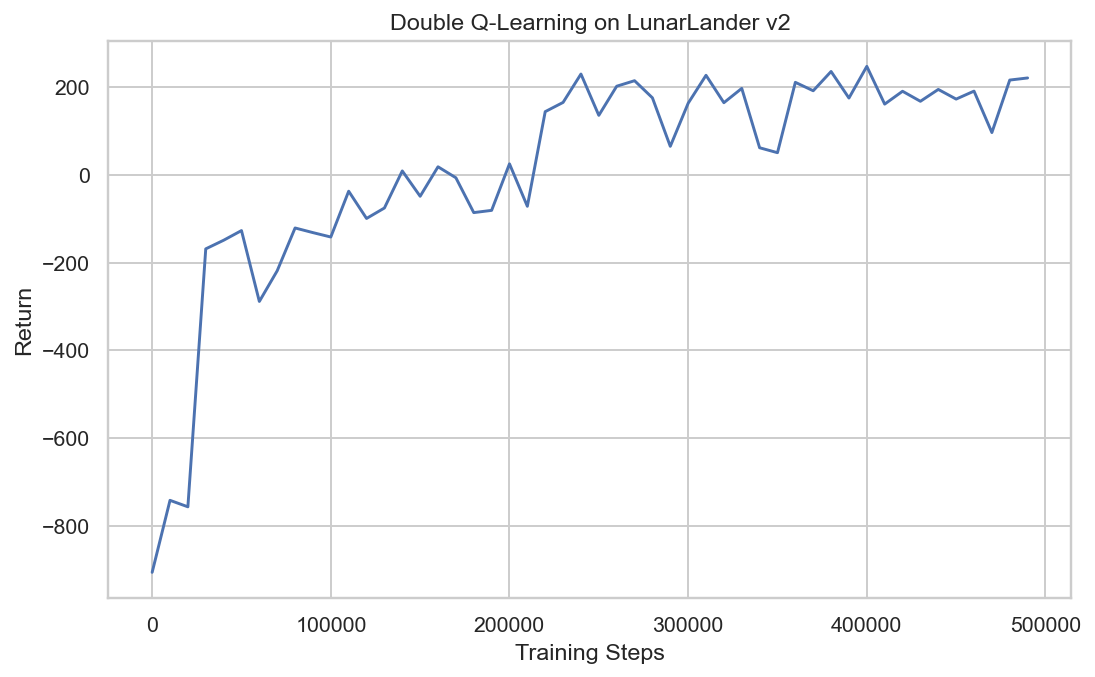

In [5]:
cartpole_lb = collect_experiments({
    'LunarLander-v2_dqn_sd1_20260312_125432': 'lunarlander_ddqn',
})
make_plot('2_5_lunarlander_ddqn.png', cartpole_lb, 'Double Q-Learning on LunarLander v2')

experiment                         run_name
      Eval MsPacman_dqn_sd1_20260312_132215
Saved figure to: C:\Users\prana\Documents\Projects\berkeley\cs285\hw\hw3\scripts\2_5_mspacman.png


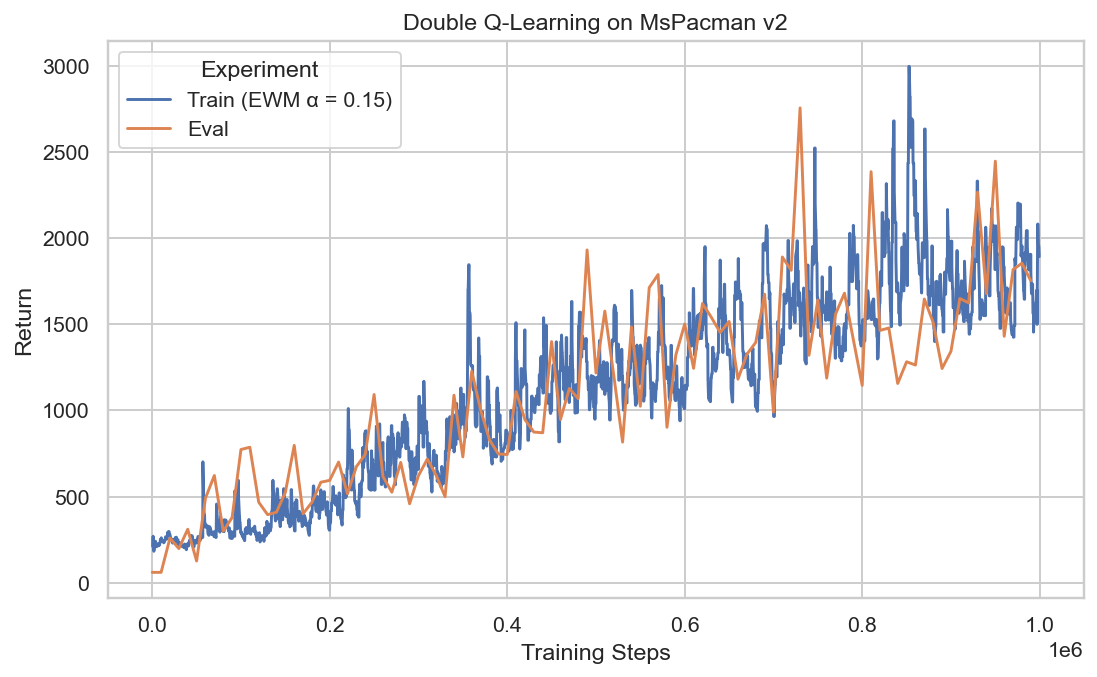

In [6]:
exp = collect_experiments({
    'MsPacman_dqn_sd1_20260312_132215': 'Eval',
})
exp_train = exp.copy()
exp_train['experiment'] = 'Train (EWM α = 0.15)'
exp_train['Eval_AverageReturn'] = exp_train['Train_EpisodeReturn'].ewm(alpha=0.15).mean()

exp = pd.concat([exp_train, exp], ignore_index=True)
# print(exp)
make_plot('2_5_mspacman.png', exp, 'Double Q-Learning on MsPacman v2')

experiment                                     run_name
   2 x 128 LunarLander-v2_dqn_2_128_sd1_20260312_135508
   3 x 128 LunarLander-v2_dqn_3_128_sd1_20260312_143143
   2 x 256       LunarLander-v2_dqn_sd1_20260312_125432
   3 x 256 LunarLander-v2_dqn_3_256_sd1_20260312_145716
Saved figure to: C:\Users\prana\Documents\Projects\berkeley\cs285\hw\hw3\scripts\2_6_lunarlander_hyper.png


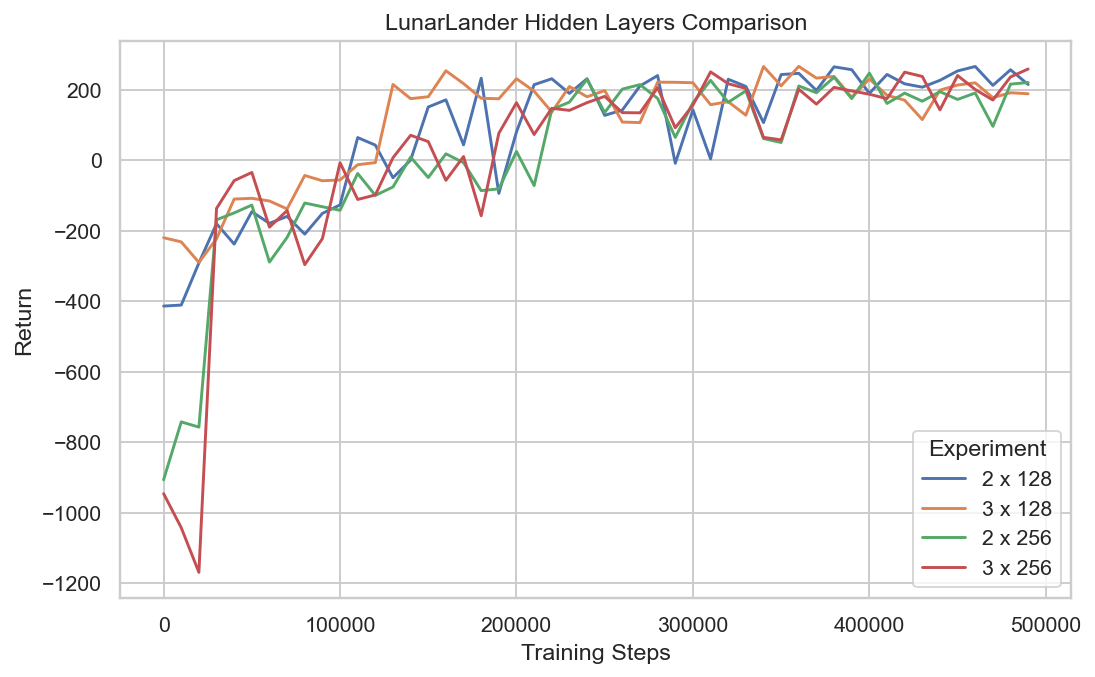

In [7]:
exp = collect_experiments({
    'LunarLander-v2_dqn_2_128_sd1_20260312_135508': '2 x 128',
    'LunarLander-v2_dqn_3_128_sd1_20260312_143143': '3 x 128',
    'LunarLander-v2_dqn_sd1_20260312_125432': '2 x 256',
    'LunarLander-v2_dqn_3_256_sd1_20260312_145716': '3 x 256',
})
make_plot('2_6_lunarlander_hyper.png', exp, 'LunarLander Hidden Layers Comparison')

experiment                               run_name
       sac HalfCheetah-v4_sac_sd1_20260312_152516
Saved figure to: C:\Users\prana\Documents\Projects\berkeley\cs285\hw\hw3\scripts\3_4_halfcheetah_sac.png


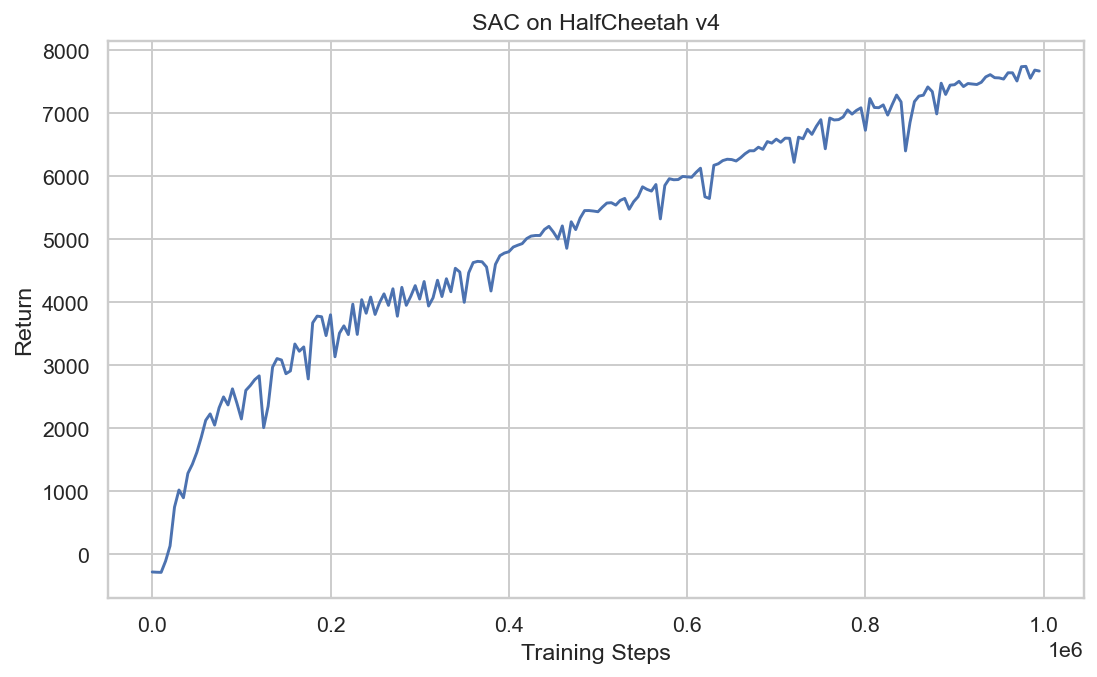

In [8]:
exp = collect_experiments({
    'HalfCheetah-v4_sac_sd1_20260312_152516': 'sac',
})
make_plot('3_4_halfcheetah_sac.png', exp, 'SAC on HalfCheetah v4')

     experiment                                        run_name
Auto-Tuned Temp HalfCheetah-v4_sac_autotune_sd1_20260312_152636
     Fixed Temp          HalfCheetah-v4_sac_sd1_20260312_152516
     experiment                                        run_name
Auto-Tuned Temp HalfCheetah-v4_sac_autotune_sd1_20260312_152636


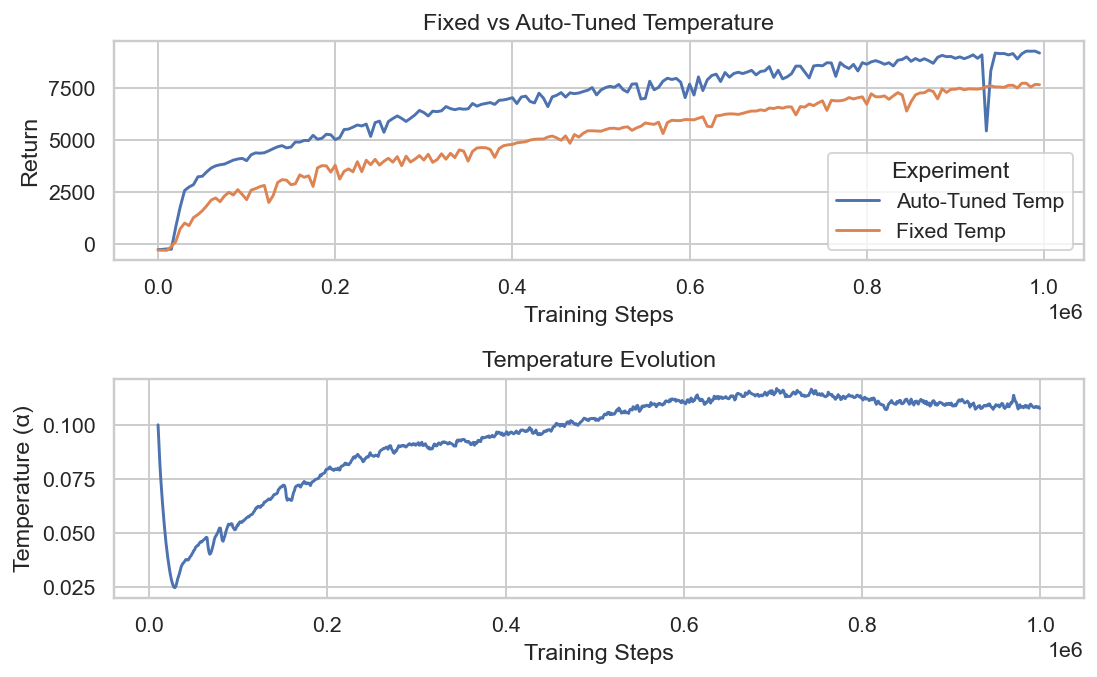

In [9]:
fig, ax = plt.subplots(2, figsize=(8, 5), dpi=140)

exp1 = collect_experiments({
    'HalfCheetah-v4_sac_autotune_sd1_20260312_152636': 'Auto-Tuned Temp',
    'HalfCheetah-v4_sac_sd1_20260312_152516': 'Fixed Temp',
})

exp2 = collect_experiments({
    'HalfCheetah-v4_sac_autotune_sd1_20260312_152636': 'Auto-Tuned Temp',
})
make_plot(ax[0], exp1, 'Fixed vs Auto-Tuned Temperature')
make_plot(ax[1], exp2, 'Temperature Evolution', y='alpha', y_label='Temperature (α)')
plt.show()

out_path = repo_root / 'scripts' / '3_5_sac_autotune.png'
fig.savefig(out_path, bbox_inches='tight')

      experiment                                  run_name
        Single-Q Hopper-v4_sac_singleq_sd1_20260312_175234
Clipped Double-Q   Hopper-v4_sac_clipq_sd1_20260312_185318
Saved figure to: C:\Users\prana\Documents\Projects\berkeley\cs285\hw\hw3\scripts\3_6_single_vs_clipped_q_reward.png


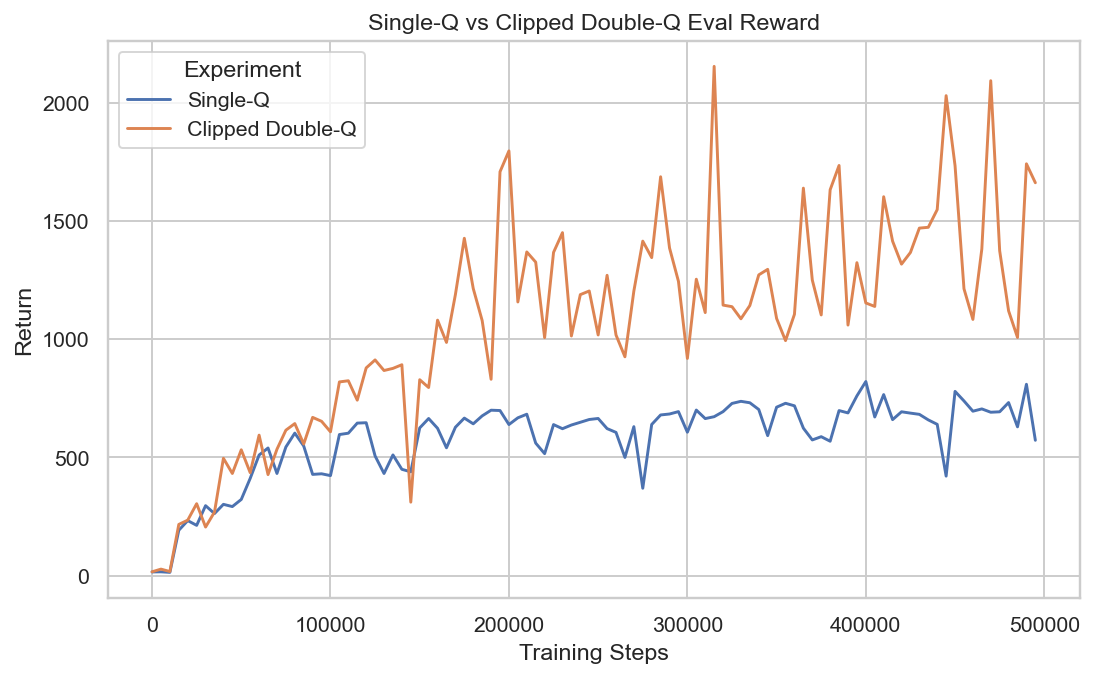

Saved figure to: C:\Users\prana\Documents\Projects\berkeley\cs285\hw\hw3\scripts\3_6_single_vs_clipped_q_qval.png


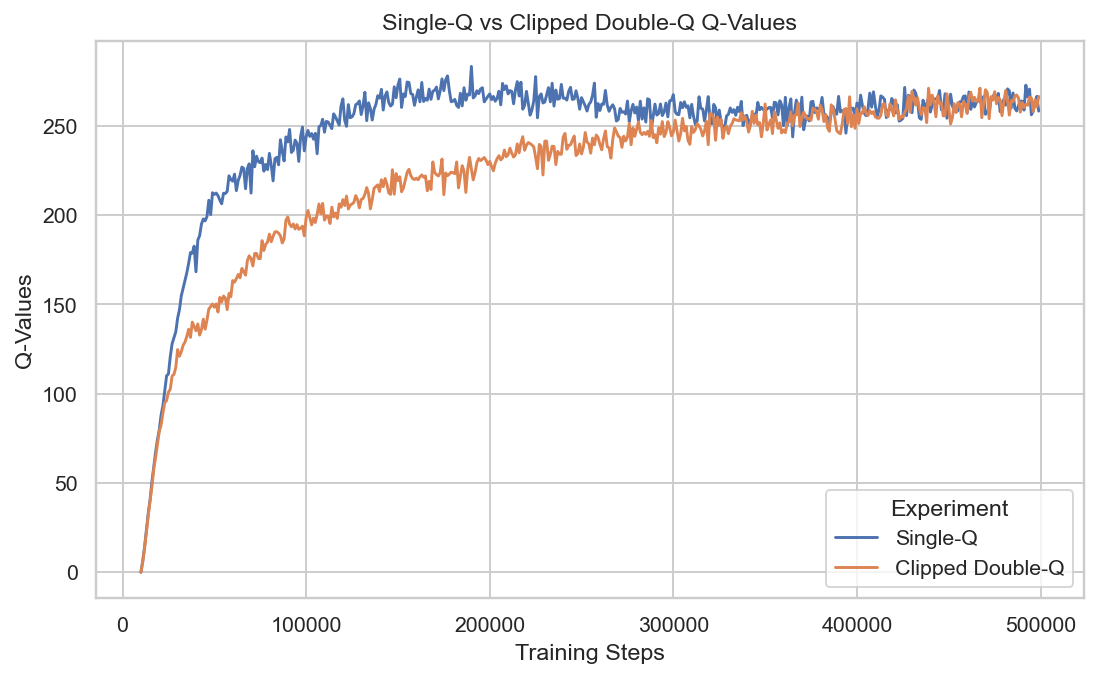

In [10]:
exp = collect_experiments({
    'Hopper-v4_sac_singleq_sd1_20260312_175234': 'Single-Q',
    'Hopper-v4_sac_clipq_sd1_20260312_185318': 'Clipped Double-Q',
})
make_plot('3_6_single_vs_clipped_q_reward.png', exp, 'Single-Q vs Clipped Double-Q Eval Reward')
make_plot('3_6_single_vs_clipped_q_qval.png', exp, 'Single-Q vs Clipped Double-Q Q-Values', y='q_values', y_label='Q-Values')
